# M3 · LightGBM (gradient boosting)

**Role:** the main candidate. M2 showed that averaging independent trees adds almost nothing over Logistic Regression. Boosting is the real test.

**How boosting works:** trees are built one after another. Each new small tree is fitted to the mistakes that all previous trees together still make, and is added with a small weight (the learning rate). The sum of all trees is the log-odds of default, and the sigmoid turns it into a PD.

Versions: **A** (189 features) and **B** (147, without LendingClub's grades; deployable). Fit on train, early-stop and choose on validation, **test sealed**. Full plan: `IMPLEMENTATION_PLAN.md`.

## 1. Setup

In [1]:
import gc, json, os, sys, time, platform
from pathlib import Path

import numpy as np
import pandas as pd
import sklearn
import lightgbm as lgb
import matplotlib.pyplot as plt

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "modeling").is_dir())
sys.path.insert(0, str(ROOT))
from src.modeling import evaluation as ev

ON_KAGGLE = Path("/kaggle/input").exists()
if ON_KAGGLE:   # data comes from the private input dataset; everything else uses the repo layout
    data_dir = next(Path("/kaggle/input").rglob("X_train.parquet")).parent
    ev.DATA_DIR, ev.METADATA_PATH = data_dir, data_dir / "metadata_v2.json"

RESULTS = ROOT / "models" / "M3_lightgbm" / "results"
RESULTS.mkdir(parents=True, exist_ok=True)
SEED, N_TRIALS, MAX_ROUNDS, EARLY_STOP, SEARCH_LR = 42, 40, 5000, 100, 0.05
print("Running on:", "Kaggle" if ON_KAGGLE else "local machine", "| data:", ev.DATA_DIR)
print("Python", platform.python_version(), "| pandas", pd.__version__, "| scikit-learn", sklearn.__version__,
      "| lightgbm", lgb.__version__, "| CPU cores", os.cpu_count())

Running on: Kaggle | data: /kaggle/input/datasets/mitanshkanani/credit-risk-model-inputs
Python 3.13.15 | pandas 2.3.3 | scikit-learn 1.6.1 | lightgbm 4.6.0 | CPU cores 4


## 2. Load data and define versions A and B (same feature sets as M1 and M2)

In [2]:
X_train, y_train_frame = ev.load_split("train")
X_val, y_val_frame = ev.load_split("validation")
y_train = y_train_frame["target"].astype(int).to_numpy()
y_val = y_val_frame["target"].astype(int).to_numpy()
meta = json.loads(ev.METADATA_PATH.read_text(encoding="utf-8"))
lc_risk = set(meta["feature_groups"]["lc_risk_features"])
features = {
    "A": [c for c in X_train.columns if c != "fico_range_high"],
    "B": [c for c in X_train.columns if c != "fico_range_high" and c not in lc_risk],
}
for v, cols in features.items():
    print(f"Version {v}: {len(cols)} features")
print(f"train {X_train.shape}, default rate {y_train.mean():.4f} | validation {X_val.shape}, default rate {y_val.mean():.4f}")

Version A: 189 features
Version B: 147 features
train (388124, 190), default rate 0.1724 | validation (162745, 190), default rate 0.2035


## 3. Training helper
LightGBM core API. Objective `binary`. Training stops when validation ROC-AUC has not improved for 100 rounds (max 5,000). Fixed: `bagging_freq=1`, `seed=42`, `deterministic=True`, all CPU threads.

In [3]:
BASE = dict(objective="binary", metric=["auc", "binary_logloss"], boosting_type="gbdt", bagging_freq=1,
            seed=SEED, deterministic=True, force_col_wise=True, num_threads=os.cpu_count(),
            verbosity=-1, feature_pre_filter=False)
_datasets = {}

def datasets(version):
    if version not in _datasets:
        cols = features[version]
        dtrain = lgb.Dataset(X_train[cols], label=y_train, free_raw_data=False, params={"feature_pre_filter": False})
        dval = lgb.Dataset(X_val[cols], label=y_val, reference=dtrain, free_raw_data=False)
        _datasets[version] = (dtrain, dval)
    return _datasets[version]

def train(version, params):
    dtrain, dval = datasets(version)
    evals = {}
    booster = lgb.train({**BASE, **params}, dtrain, num_boost_round=MAX_ROUNDS, valid_sets=[dval],
                        valid_names=["validation"],
                        callbacks=[lgb.early_stopping(EARLY_STOP, first_metric_only=True, verbose=False),
                                   lgb.record_evaluation(evals)])
    return booster, evals

def predict(booster, version, X):
    return booster.predict(X[features[version]], num_iteration=booster.best_iteration)

## 4. Random search: 40 settings per version (learning rate 0.05)
Trial 0 is the untuned baseline from the plan (31 leaves, 200 loans per leaf). The same 40 settings are tried for A and B.

In [4]:
rng = np.random.default_rng(SEED)
def log_uniform(low, high):
    return float(np.exp(rng.uniform(np.log(low), np.log(high))))

configs = [{"num_leaves": 31, "min_data_in_leaf": 200, "feature_fraction": 0.7, "bagging_fraction": 0.8,
            "lambda_l1": 0.0, "lambda_l2": 1.0, "min_gain_to_split": 0.0}]
for _ in range(N_TRIALS - 1):
    configs.append({"num_leaves": int(round(log_uniform(15, 255))), "min_data_in_leaf": int(round(log_uniform(20, 2000))),
                    "feature_fraction": round(rng.uniform(0.4, 1.0), 3), "bagging_fraction": round(rng.uniform(0.5, 1.0), 3),
                    "lambda_l1": log_uniform(1e-4, 10), "lambda_l2": log_uniform(1e-4, 10),
                    "min_gain_to_split": round(rng.uniform(0.0, 0.5), 3)})

rows = []
for version in ("A", "B"):
    start_version = time.time()
    for trial, cfg in enumerate(configs):
        start = time.time()
        booster, _ = train(version, {**cfg, "learning_rate": SEARCH_LR})
        card = ev.report_card(y_val, predict(booster, version, X_val))
        rows.append({"version": version, "trial": trial, **cfg, "best_iteration": booster.best_iteration,
                     "val_roc_auc": card["roc_auc"], "val_ks": card["ks"], "val_brier": card["brier"],
                     "val_log_loss": card["log_loss"], "val_mean_pd": card["mean_pd"], "seconds": round(time.time() - start, 1)})
        del booster
        if trial % 10 == 9 or trial == len(configs) - 1:
            best = max(r["val_roc_auc"] for r in rows if r["version"] == version)
            print(f"{version}: {trial + 1}/{len(configs)} settings done, best validation AUC so far {best:.4f}")
    print(f"Version {version} search: {(time.time() - start_version) / 60:.1f} min")
tuning = pd.DataFrame(rows)
tuning.sort_values(["version", "val_roc_auc"], ascending=[True, False]).groupby("version").head(8).round(4)

A: 10/40 settings done, best validation AUC so far 0.7404
A: 20/40 settings done, best validation AUC so far 0.7407
A: 30/40 settings done, best validation AUC so far 0.7410
A: 40/40 settings done, best validation AUC so far 0.7410
Version A search: 27.8 min
B: 10/40 settings done, best validation AUC so far 0.7350
B: 20/40 settings done, best validation AUC so far 0.7354
B: 30/40 settings done, best validation AUC so far 0.7354
B: 40/40 settings done, best validation AUC so far 0.7356
Version B search: 27.4 min


,version,trial,num_leaves,min_data_in_leaf,feature_fraction,bagging_fraction,lambda_l1,lambda_l2,min_gain_to_split,best_iteration,val_roc_auc,val_ks,val_brier,val_log_loss,val_mean_pd,seconds
20,A,20,40,304,0.414,0.979,0.0258,0.8197,0.041,761,0.7410,0.3515,0.1423,0.4450,0.1801,54.6
33,A,33,34,1415,0.415,0.778,0.1479,0.0003,0.070,605,0.7409,0.3503,0.1422,0.4447,0.1812,46.5
25,A,25,37,1610,0.575,0.758,0.0019,4.7887,0.082,528,0.7409,0.3497,0.1422,0.4449,0.1801,46.0
32,A,32,21,1433,0.639,0.650,0.0277,0.2062,0.478,747,0.7408,0.3508,0.1423,0.4450,0.1797,51.5
15,A,15,21,1678,0.945,0.850,0.0021,7.0126,0.389,654,0.7407,0.3497,0.1423,0.4452,0.1785,54.5
23,A,23,20,442,0.569,0.830,0.4315,0.6970,0.054,743,0.7406,0.3500,0.1424,0.4453,0.1789,49.8
28,A,28,32,1495,0.545,0.561,1.4307,0.0006,0.090,552,0.7406,0.3494,0.1424,0.4451,0.1800,43.4
9,A,9,55,274,0.484,0.557,0.2198,0.0227,0.283,417,0.7404,0.3505,0.1424,0.4453,0.1799,35.0
72,B,32,21,1433,0.639,0.650,0.0277,0.2062,0.478,849,0.7356,0.3403,0.1428,0.4467,0.1864,55.5
73,B,33,34,1415,0.415,0.778,0.1479,0.0003,0.070,596,0.7355,0.3424,0.1428,0.4467,0.1865,44.2


### Selection rule
Highest validation ROC-AUC. Within 0.0005 of the best, prefer fewer leaves (simpler model).

In [5]:
PARAM_KEYS = ["num_leaves", "min_data_in_leaf", "feature_fraction", "bagging_fraction",
              "lambda_l1", "lambda_l2", "min_gain_to_split"]
chosen = {}
for version, part in tuning.groupby("version"):
    best = part["val_roc_auc"].max()
    pick = part[part["val_roc_auc"] >= best - 0.0005].sort_values(["num_leaves", "val_roc_auc"], ascending=[True, False]).iloc[0]
    chosen[version] = {k: (int(pick[k]) if k in ("num_leaves", "min_data_in_leaf") else float(pick[k])) for k in PARAM_KEYS}
    print(f"Version {version}: best AUC {best:.4f}; chosen trial {int(pick['trial'])} (AUC {pick['val_roc_auc']:.4f}, "
          f"{int(pick['best_iteration'])} rounds): {chosen[version]}")
baseline = tuning[tuning.trial == 0].set_index("version")["val_roc_auc"]
print("\nUntuned baseline (trial 0):", baseline.round(4).to_dict())

Version A: best AUC 0.7410; chosen trial 23 (AUC 0.7406, 743 rounds): {'num_leaves': 20, 'min_data_in_leaf': 442, 'feature_fraction': 0.569, 'bagging_fraction': 0.83, 'lambda_l1': 0.4314923211815454, 'lambda_l2': 0.6970075133727107, 'min_gain_to_split': 0.054}
Version B: best AUC 0.7356; chosen trial 32 (AUC 0.7356, 849 rounds): {'num_leaves': 21, 'min_data_in_leaf': 1433, 'feature_fraction': 0.639, 'bagging_fraction': 0.65, 'lambda_l1': 0.027728107350228473, 'lambda_l2': 0.20621538523149052, 'min_gain_to_split': 0.478}

Untuned baseline (trial 0): {'A': 0.7403, 'B': 0.7346}


## 5. Follow-up experiments on the chosen setting
1. **Learning rate 0.02** (smaller steps, more trees): kept only if validation AUC improves by at least 0.0005.
2. **`is_unbalance=True`** (up-weights defaults).
3. **Monotonic constraints (version B)**: FICO ↓, DTI ↑, income ↓, 60-month term ↑, recent inquiries ↑, revolving utilisation ↑ risk.

In [6]:
experiments, models, evals_by_model, final_lr = [], {}, {}, {}

def record(name, version, booster, note):
    card = ev.report_card(y_val, predict(booster, version, X_val))
    experiments.append({"experiment": name, "version": version, "rounds": booster.best_iteration,
                        "val_roc_auc": card["roc_auc"], "val_ks": card["ks"], "val_brier": card["brier"],
                        "val_log_loss": card["log_loss"], "val_mean_pd": card["mean_pd"], "note": note})
    return card

for version in ("A", "B"):
    b05, e05 = train(version, {**chosen[version], "learning_rate": 0.05})
    c05 = record("chosen, lr 0.05", version, b05, "search setting")
    b02, e02 = train(version, {**chosen[version], "learning_rate": 0.02})
    c02 = record("chosen, lr 0.02", version, b02, "finer steps")
    if c02["roc_auc"] >= c05["roc_auc"] + 0.0005:
        models[version], evals_by_model[version], final_lr[version] = b02, e02, 0.02
    else:
        models[version], evals_by_model[version], final_lr[version] = b05, e05, 0.05
    bu, _ = train(version, {**chosen[version], "learning_rate": final_lr[version], "is_unbalance": True})
    record("is_unbalance=True", version, bu, "up-weights defaults")
    del bu; gc.collect()

MONOTONE = {"fico_range_low": -1, "dti": +1, "annual_inc": -1, "term_months": +1, "inq_last_6mths": +1, "revol_util": +1}
mono_vector = [MONOTONE.get(c, 0) for c in features["B"]]
features["B-mono"] = features["B"]
_datasets["B-mono"] = datasets("B")
bm, em = train("B-mono", {**chosen["B"], "learning_rate": final_lr["B"], "monotone_constraints": mono_vector,
                          "monotone_constraints_method": "advanced"})
record("monotonic constraints", "B", bm, ", ".join(f"{k} {'+' if v > 0 else '-'}" for k, v in MONOTONE.items()))
models["B-mono"], evals_by_model["B-mono"], final_lr["B-mono"] = bm, em, final_lr["B"]
experiments = pd.DataFrame(experiments)
print("Final learning rate:", final_lr)
experiments.round(4)

Final learning rate: {'A': 0.02, 'B': 0.02, 'B-mono': 0.02}


,experiment,version,rounds,val_roc_auc,val_ks,val_brier,val_log_loss,val_mean_pd,note
0,"chosen, lr 0.05",A,743,0.7406,0.3500,0.1424,0.4453,0.1789,search setting
1,"chosen, lr 0.02",A,2961,0.7414,0.3519,0.1422,0.4448,0.1792,finer steps
2,is_unbalance=True,A,1836,0.7411,0.3507,0.2059,0.5954,0.4453,up-weights defaults
3,"chosen, lr 0.05",B,849,0.7356,0.3403,0.1428,0.4467,0.1864,search setting
4,"chosen, lr 0.02",B,2279,0.7362,0.3415,0.1426,0.4463,0.1869,finer steps
5,is_unbalance=True,B,2173,0.7362,0.3414,0.2149,0.6161,0.4620,up-weights defaults
6,monotonic constraints,B,1853,0.7354,0.3400,0.1428,0.4467,0.1870,"fico_range_low -, dti +, annual_inc -, term_mo..."


## 6. Score the final models

In [7]:
preds, cards = {}, {}
for name, booster in models.items():
    version = "B" if name == "B-mono" else name
    preds[name] = {"train": predict(booster, name, X_train), "validation": predict(booster, name, X_val)}
    cards[name] = {s: ev.report_card(y, preds[name][s]) for s, y in (("train", y_train), ("validation", y_val))}

board = pd.read_csv(ev.LEADERBOARD_PATH)
keys = ["roc_auc", "ks", "pr_auc", "brier", "log_loss", "mean_pd", "calibration_gap"]
def board_row(model, version, split="validation"):
    r = board[(board.model == model) & (board.version == version) & (board.split == split)].iloc[0]
    return {k: r[k] for k in keys}
compare = pd.DataFrame({
    "M0": board_row("M0", "A"),
    "M1-A": board_row("M1", "A"), "M2-A": board_row("M2", "A"), "M3-A": {k: cards["A"]["validation"][k] for k in keys},
    "M1-B": board_row("M1", "B"), "M2-B": board_row("M2", "B"), "M3-B": {k: cards["B"]["validation"][k] for k in keys},
    "M3-B-mono": {k: cards["B-mono"]["validation"][k] for k in keys},
    "M3-B (train)": {k: cards["B"]["train"][k] for k in keys},
})
print("Validation unless marked")
compare.astype(float).round(4)

Validation unless marked


,M0,M1-A,M2-A,M3-A,M1-B,M2-B,M3-B,M3-B-mono,M3-B (train)
roc_auc,0.5000,0.7335,0.7345,0.7414,0.7252,0.7270,0.7362,0.7354,0.7567
ks,0.0000,0.3421,0.3410,0.3519,0.3262,0.3284,0.3415,0.3400,0.3773
pr_auc,0.2035,0.4120,0.4152,0.4250,0.4045,0.4084,0.4210,0.4201,0.4036
brier,0.1631,0.1445,0.1443,0.1422,0.1449,0.1467,0.1426,0.1428,0.1242
log_loss,0.5085,0.4506,0.4503,0.4448,0.4529,0.4571,0.4463,0.4467,0.3980
mean_pd,0.1724,0.1773,0.1749,0.1792,0.1837,0.1817,0.1869,0.1870,0.1725
calibration_gap,-0.0311,-0.0262,-0.0286,-0.0243,-0.0198,-0.0218,-0.0167,-0.0165,0.0000


In [8]:
for v in ("A", "B"):
    m3 = cards[v]["validation"]
    for prev in ("M1", "M2"):
        r = board_row(prev, v)
        print(f"Version {v}: M3 - {prev} -> ROC-AUC {m3['roc_auc'] - r['roc_auc']:+.4f}, KS {m3['ks'] - r['ks']:+.4f}, "
              f"Brier {m3['brier'] - r['brier']:+.4f}, log loss {m3['log_loss'] - r['log_loss']:+.4f}")

Version A: M3 - M1 -> ROC-AUC +0.0079, KS +0.0098, Brier -0.0022, log loss -0.0058
Version A: M3 - M2 -> ROC-AUC +0.0069, KS +0.0108, Brier -0.0021, log loss -0.0054
Version B: M3 - M1 -> ROC-AUC +0.0110, KS +0.0153, Brier -0.0022, log loss -0.0066
Version B: M3 - M2 -> ROC-AUC +0.0092, KS +0.0131, Brier -0.0041, log loss -0.0108


## 7. Sanity checks

In [9]:
m0 = board_row("M0", "A")
checks = []
for name in models:
    val, tr = cards[name]["validation"], cards[name]["train"]
    checks += [
        (name, "early stopping triggered (< max rounds)", models[name].best_iteration < MAX_ROUNDS, f"{models[name].best_iteration} rounds"),
        (name, "beats M0 ROC-AUC and Brier", val["roc_auc"] > m0["roc_auc"] and val["brier"] < m0["brier"],
         f"AUC {val['roc_auc']:.4f}, Brier {val['brier']:.4f}"),
        (name, "below 0.80 leakage flag", val["roc_auc"] < 0.80, f"{val['roc_auc']:.4f}"),
        (name, "train vs validation ROC-AUC (info)", True, f"{tr['roc_auc']:.4f} vs {val['roc_auc']:.4f}"),
    ]
pd.DataFrame(checks, columns=["model", "check", "passed", "detail"])

,model,check,passed,detail
0,A,early stopping triggered (< max rounds),True,2961 rounds
1,A,beats M0 ROC-AUC and Brier,True,"AUC 0.7414, Brier 0.1422"
2,A,below 0.80 leakage flag,True,0.7414
3,A,train vs validation ROC-AUC (info),True,0.7704 vs 0.7414
4,B,early stopping triggered (< max rounds),True,2279 rounds
5,B,beats M0 ROC-AUC and Brier,True,"AUC 0.7362, Brier 0.1426"
6,B,below 0.80 leakage flag,True,0.7362
7,B,train vs validation ROC-AUC (info),True,0.7567 vs 0.7362
8,B-mono,early stopping triggered (< max rounds),True,1853 rounds
9,B-mono,beats M0 ROC-AUC and Brier,True,"AUC 0.7354, Brier 0.1428"


## 8. Learning curve: validation AUC per boosting round

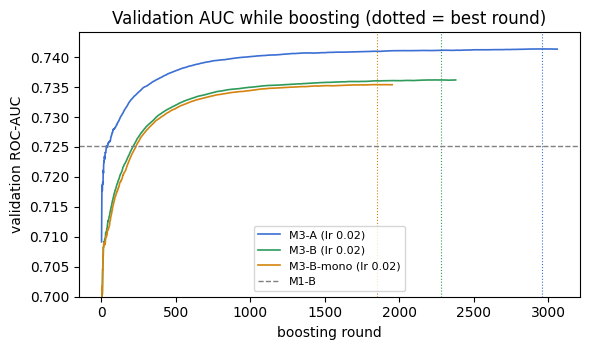

In [10]:
fig, ax = plt.subplots(figsize=(6, 3.6))
for name, color in (("A", "#3b6fd4"), ("B", "#2e9b5b"), ("B-mono", "#d4840f")):
    auc = evals_by_model[name]["validation"]["auc"]
    ax.plot(range(1, len(auc) + 1), auc, color=color, lw=1.2, label=f"M3-{name} (lr {final_lr[name]})")
    ax.axvline(models[name].best_iteration, color=color, ls=":", lw=0.8)
ax.axhline(board_row("M1", "B")["roc_auc"], color="grey", ls="--", lw=1, label="M1-B")
ax.set_xlabel("boosting round"); ax.set_ylabel("validation ROC-AUC"); ax.set_ylim(0.70, None)
ax.set_title("Validation AUC while boosting (dotted = best round)"); ax.legend(fontsize=8); plt.tight_layout()
plt.savefig(RESULTS / "m3_learning_curve.png", dpi=150); plt.show()

## 9. SHAP explanations (version B)
LightGBM computes exact SHAP values for trees (`pred_contrib=True`). For each loan, the contributions add up (with the base value) to the model's log-odds, so they say how much each feature pushed **this** applicant's risk up or down. This is exactly what the decision layer needs for reason codes.

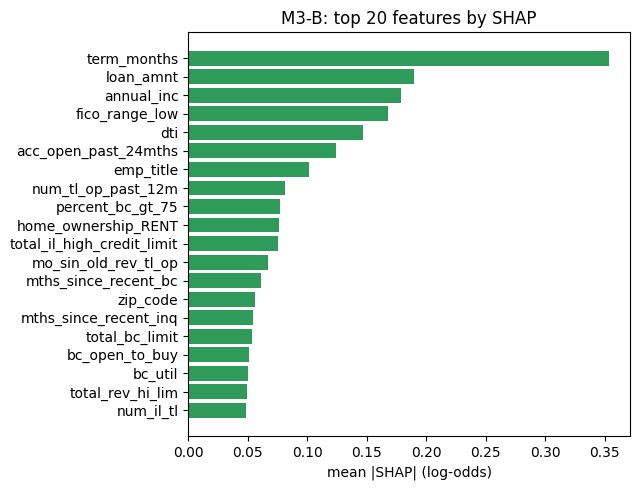

,feature,mean_abs_shap,mean_shap
0,term_months,0.3535,-0.0026
1,loan_amnt,0.1900,-0.0111
2,annual_inc,0.1790,-0.0042
3,fico_range_low,0.1675,0.0071
4,dti,0.1468,0.0256
5,acc_open_past_24mths,0.1242,0.0226
6,emp_title,0.1015,0.0097
7,num_tl_op_past_12m,0.0811,0.0138
8,percent_bc_gt_75,0.0775,-0.0131
9,home_ownership_RENT,0.0767,-0.0042


In [11]:
sample_idx = np.random.default_rng(SEED).choice(len(X_val), size=20000, replace=False)
X_s = X_val.iloc[sample_idx][features["B"]]
contrib = models["B"].predict(X_s, num_iteration=models["B"].best_iteration, pred_contrib=True)
shap_vals, base_value = contrib[:, :-1], contrib[0, -1]
shap_imp = (pd.DataFrame({"feature": features["B"], "mean_abs_shap": np.abs(shap_vals).mean(axis=0),
                          "mean_shap": shap_vals.mean(axis=0)})
            .sort_values("mean_abs_shap", ascending=False).reset_index(drop=True))
top = shap_imp.head(20).iloc[::-1]
fig, ax = plt.subplots(figsize=(6.5, 5))
ax.barh(top["feature"], top["mean_abs_shap"], color="#2e9b5b")
ax.set_xlabel("mean |SHAP| (log-odds)"); ax.set_title("M3-B: top 20 features by SHAP"); plt.tight_layout()
plt.savefig(RESULTS / "m3_shap.png", dpi=150); plt.show()
shap_imp.head(20).round(4)

In [12]:
# One example applicant from the riskiest 10% of the sample: why did the model score them this way?
pd_s = predict(models["B"], "B", X_val.iloc[sample_idx])
row = int(np.flatnonzero(pd_s >= np.quantile(pd_s, 0.9))[0])
contrib_row = pd.Series(shap_vals[row], index=features["B"])
loan = X_s.iloc[row]
example = (pd.DataFrame({"feature": contrib_row.index, "value": loan.values, "shap_log_odds": contrib_row.values})
           .assign(abs_shap=lambda d: d.shap_log_odds.abs()).sort_values("abs_shap", ascending=False).head(8)
           .drop(columns="abs_shap").reset_index(drop=True))
example["direction"] = np.where(example["shap_log_odds"] > 0, "raises risk", "lowers risk")
print(f"Example applicant: PD {pd_s[row]:.1%} (average validation PD {cards['B']['validation']['mean_pd']:.1%}); "
      f"actually defaulted: {bool(y_val[sample_idx][row])}")
print(f"Base log-odds {base_value:.3f} + sum of contributions {contrib_row.sum():.3f} = {base_value + contrib_row.sum():.3f} "
      f"-> PD {1 / (1 + np.exp(-(base_value + contrib_row.sum()))):.1%}")
example.round(4)

Example applicant: PD 53.5% (average validation PD 18.7%); actually defaulted: True
Base log-odds -1.805 + sum of contributions 1.947 = 0.142 -> PD 53.5%


,feature,value,shap_log_odds,direction
0,term_months,60.0000,0.6416,raises risk
1,acc_open_past_24mths,12.0000,0.3395,raises risk
2,fico_range_low,660.0000,0.2540,raises risk
3,emp_title,0.2329,0.2093,raises risk
4,inq_last_6mths,4.0000,0.1662,raises risk
5,mths_since_recent_bc,1.0000,0.1450,raises risk
6,percent_bc_gt_75,11.1000,-0.1340,lowers risk
7,mths_since_recent_inq,0.0000,0.0906,raises risk


## 10. Calibration on validation

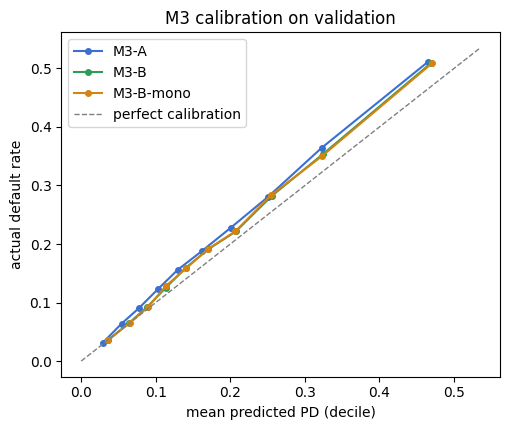

,predicted,actual,model
bin,,,
0,0.0287,0.0310,A
1,0.0542,0.0640,A
2,0.0777,0.0908,A
3,0.1024,0.1223,A
4,0.1297,0.1563,A
5,0.1615,0.1877,A
6,0.2003,0.2275,A
7,0.2505,0.2805,A
8,0.3223,0.3641,A


In [13]:
fig, ax = plt.subplots(figsize=(5.2, 4.4))
calib_rows = []
for name, color in (("A", "#3b6fd4"), ("B", "#2e9b5b"), ("B-mono", "#d4840f")):
    frame = pd.DataFrame({"p": preds[name]["validation"], "y": y_val})
    frame["bin"] = pd.qcut(frame["p"], 10, labels=False, duplicates="drop")
    g = frame.groupby("bin").agg(predicted=("p", "mean"), actual=("y", "mean"))
    ax.plot(g["predicted"], g["actual"], marker="o", color=color, label=f"M3-{name}", ms=4)
    calib_rows.append(g.assign(model=name))
lim = max(ax.get_xlim()[1], ax.get_ylim()[1])
ax.plot([0, lim], [0, lim], ls="--", color="grey", lw=1, label="perfect calibration")
ax.set_xlabel("mean predicted PD (decile)"); ax.set_ylabel("actual default rate")
ax.set_title("M3 calibration on validation"); ax.legend(); plt.tight_layout()
plt.savefig(RESULTS / "m3_calibration.png", dpi=150); plt.show()
pd.concat(calib_rows).round(4)

## 11. Approval-rate vs bad-rate curve (validation, version B)

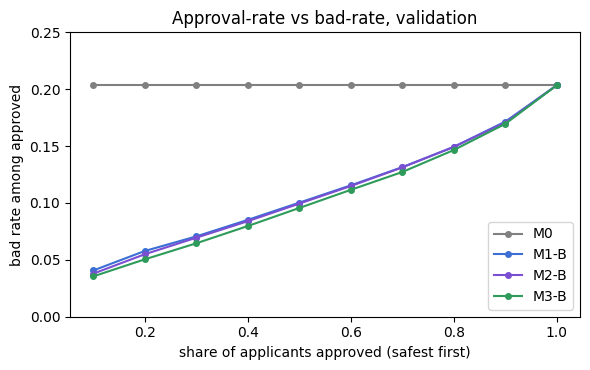

Rank agreement with M3-B (Spearman): M1-B 0.9343 | M2-B 0.9428


model,M0,M1-B,M2-B,M3-B
approval_rate,,,,
0.1,0.2035,0.0406,0.0379,0.0355
0.2,0.2035,0.0578,0.0549,0.0504
0.3,0.2035,0.0706,0.0695,0.0645
0.4,0.2035,0.0851,0.0840,0.0797
0.5,0.2035,0.1003,0.0994,0.0956
0.6,0.2035,0.1155,0.1149,0.1115
0.7,0.2035,0.1315,0.1313,0.1272
0.8,0.2035,0.1493,0.1493,0.1465
0.9,0.2035,0.1715,0.1707,0.1696


In [14]:
m1_pred = pd.read_parquet(ROOT / "models" / "M1_logistic_regression" / "results" / "m1_B_validation_pd.parquet")
m2_pred = pd.read_parquet(ROOT / "models" / "M2_random_forest" / "results" / "m2_validation_pd.parquet")
ids = y_val_frame["id"].astype(str).to_numpy()
assert (m1_pred["id"].astype(str).to_numpy() == ids).all() and (m2_pred["id"].astype(str).to_numpy() == ids).all()
curves = pd.concat([
    ev.approval_curve(y_val, np.full(len(y_val), m0["mean_pd"])).assign(model="M0"),
    ev.approval_curve(y_val, m1_pred["pd_m1_B"].to_numpy()).assign(model="M1-B"),
    ev.approval_curve(y_val, m2_pred["pd_m2_B"].to_numpy()).assign(model="M2-B"),
    ev.approval_curve(y_val, preds["B"]["validation"]).assign(model="M3-B"),
])
fig, ax = plt.subplots(figsize=(6, 3.8))
for name, color in (("M0", "grey"), ("M1-B", "#3b6fd4"), ("M2-B", "#7a4fd1"), ("M3-B", "#2e9b5b")):
    part = curves[curves.model == name]
    ax.plot(part["approval_rate"], part["bad_rate_among_approved"], marker="o", ms=4, color=color, label=name)
ax.set_xlabel("share of applicants approved (safest first)"); ax.set_ylabel("bad rate among approved")
ax.set_title("Approval-rate vs bad-rate, validation"); ax.legend(); ax.set_ylim(0, 0.25); plt.tight_layout()
plt.savefig(RESULTS / "m3_approval_curve.png", dpi=150); plt.show()
print("Rank agreement with M3-B (Spearman): M1-B", round(m1_pred["pd_m1_B"].corr(pd.Series(preds["B"]["validation"]), method="spearman"), 4),
      "| M2-B", round(m2_pred["pd_m2_B"].corr(pd.Series(preds["B"]["validation"]), method="spearman"), 4))
curves.pivot(index="approval_rate", columns="model", values="bad_rate_among_approved").round(4)

## 12. Segments, A vs B, and the cost of monotonic constraints

In [15]:
segments = pd.concat([
    ev.segment_report(y_val, preds[name]["validation"], X_val["term_months"], "term_months").assign(model=name)
    for name in models
])
a, b, bm_ = cards["A"]["validation"], cards["B"]["validation"], cards["B-mono"]["validation"]
print(f"A minus B: ROC-AUC {a['roc_auc'] - b['roc_auc']:+.4f}; B keeps {(b['roc_auc'] - 0.5) / (a['roc_auc'] - 0.5):.1%} "
      "of A's ranking power above a coin flip")
print(f"B-mono minus B: ROC-AUC {bm_['roc_auc'] - b['roc_auc']:+.4f}, Brier {bm_['brier'] - b['brier']:+.4f}")
segments[["model", "term_months", "rows", "default_rate", "mean_pd", "calibration_gap", "roc_auc", "ks", "brier"]].round(4)

A minus B: ROC-AUC +0.0052; B keeps 97.9% of A's ranking power above a coin flip
B-mono minus B: ROC-AUC -0.0008, Brier +0.0001


,model,term_months,rows,default_rate,mean_pd,calibration_gap,roc_auc,ks,brier
0,A,36.0,120790,0.1512,0.1355,-0.0157,0.7091,0.3064,0.1193
1,A,60.0,41955,0.3540,0.3050,-0.0489,0.6891,0.2789,0.2083
0,B,36.0,120790,0.1512,0.1424,-0.0089,0.7009,0.2937,0.1199
1,B,60.0,41955,0.3540,0.3149,-0.0391,0.6856,0.2710,0.2082
0,B-mono,36.0,120790,0.1512,0.1425,-0.0087,0.7000,0.2928,0.1200
1,B-mono,60.0,41955,0.3540,0.3149,-0.0391,0.6845,0.2678,0.2084


## 13. Save results
LightGBM models are small text files, so they are saved (also on Kaggle).

In [16]:
tuning.to_csv(RESULTS / "m3_tuning_results.csv", index=False)
experiments.to_csv(RESULTS / "m3_experiments.csv", index=False)
shap_imp.to_csv(RESULTS / "m3_shap_importance.csv", index=False)
example.to_csv(RESULTS / "m3_example_explanation.csv", index=False)
segments.to_csv(RESULTS / "m3_segment_metrics.csv", index=False)
curves.to_csv(RESULTS / "m3_approval_curve.csv", index=False)
pd.DataFrame({"id": ids, **{f"pd_m3_{n.replace('-', '_')}": preds[n]["validation"] for n in models}}).to_parquet(
    RESULTS / "m3_validation_pd.parquet", index=False)
for name, booster in models.items():
    booster.save_model(str(RESULTS / f"m3_{name.replace('-', '_')}.txt"), num_iteration=booster.best_iteration)
summary = {
    "model": "M3", "name": "LightGBM", "estimator": "lightgbm.train (gbdt)",
    "fixed_parameters": {k: v for k, v in BASE.items() if k != "num_threads"},
    "search": {"type": "random search", "settings_per_version": N_TRIALS, "learning_rate": SEARCH_LR,
               "early_stopping_rounds": EARLY_STOP, "max_rounds": MAX_ROUNDS,
               "ranges": {"num_leaves": [15, 255], "min_data_in_leaf": [20, 2000], "feature_fraction": [0.4, 1.0],
                          "bagging_fraction": [0.5, 1.0], "lambda_l1": [1e-4, 10], "lambda_l2": [1e-4, 10],
                          "min_gain_to_split": [0, 0.5]}},
    "selection_rule": "max validation ROC-AUC; within 0.0005 prefer fewer leaves; lr 0.02 kept only if +0.0005",
    "chosen": chosen, "final_learning_rate": final_lr,
    "best_iteration": {n: int(b.best_iteration) for n, b in models.items()},
    "monotone_constraints": MONOTONE, "n_features": {v: len(features[v]) for v in ("A", "B")},
    "environment": {"python": platform.python_version(), "pandas": pd.__version__, "scikit_learn": sklearn.__version__,
                    "lightgbm": lgb.__version__, "platform": "Kaggle CPU notebook" if ON_KAGGLE else "local",
                    "cpu_cores": os.cpu_count()},
    "metrics": cards, "test_split": "sealed",
}
(RESULTS / "m3_metrics.json").write_text(json.dumps(summary, indent=2), encoding="utf-8")
for name in models:
    cfg = chosen["B" if name == "B-mono" else name]
    note = (f"lr={final_lr[name]}, rounds={models[name].best_iteration}, leaves={cfg['num_leaves']}, "
            f"min_leaf={cfg['min_data_in_leaf']}" + (", monotone" if name == "B-mono" else ""))
    for split in ("train", "validation"):
        board = ev.update_leaderboard("M3", name, split, cards[name][split], notes=note)
print("Saved:", sorted(p.name for p in RESULTS.iterdir()))
board[board.split == "validation"].round(4)

Saved: ['m3_A.txt', 'm3_B.txt', 'm3_B_mono.txt', 'm3_approval_curve.csv', 'm3_approval_curve.png', 'm3_calibration.png', 'm3_example_explanation.csv', 'm3_experiments.csv', 'm3_learning_curve.png', 'm3_metrics.json', 'm3_segment_metrics.csv', 'm3_shap.png', 'm3_shap_importance.csv', 'm3_tuning_results.csv', 'm3_validation_pd.parquet']


,model,version,split,rows,default_rate,mean_pd,roc_auc,pr_auc,ks,brier,log_loss,calibration_gap,notes
1,M0,A,validation,162745,0.2035,0.1724,0.5000,0.2035,0.0000,0.1631,0.5085,-0.0311,constant PD = train default rate
3,M0,B,validation,162745,0.2035,0.1724,0.5000,0.2035,0.0000,0.1631,0.5085,-0.0311,constant PD = train default rate
5,M1,A,validation,162745,0.2035,0.1773,0.7335,0.4120,0.3421,0.1445,0.4506,-0.0262,"log+scale, C=0.0001, class_weight=None"
7,M1,B,validation,162745,0.2035,0.1837,0.7252,0.4045,0.3262,0.1449,0.4529,-0.0198,"log+scale, C=0.001, class_weight=None"
9,M2,A,validation,162745,0.2035,0.1749,0.7345,0.4152,0.3410,0.1443,0.4503,-0.0286,"500 trees, leaf=50, max_features=0.3, class_we..."
11,M2,B,validation,162745,0.2035,0.1817,0.7270,0.4084,0.3284,0.1467,0.4571,-0.0218,"500 trees, leaf=20, max_features=sqrt, class_w..."
13,M3,A,validation,162745,0.2035,0.1792,0.7414,0.4250,0.3519,0.1422,0.4448,-0.0243,"lr=0.02, rounds=2961, leaves=20, min_leaf=442"
15,M3,B,validation,162745,0.2035,0.1869,0.7362,0.4210,0.3415,0.1426,0.4463,-0.0167,"lr=0.02, rounds=2279, leaves=21, min_leaf=1433"
17,M3,B-mono,validation,162745,0.2035,0.1870,0.7354,0.4201,0.3400,0.1428,0.4467,-0.0165,"lr=0.02, rounds=1853, leaves=21, min_leaf=1433..."


## 14. Conclusion

In [17]:
for v in ("A", "B"):
    print(f"Version {v}: ROC-AUC M1 {board_row('M1', v)['roc_auc']:.4f} | M2 {board_row('M2', v)['roc_auc']:.4f} | "
          f"M3 {cards[v]['validation']['roc_auc']:.4f};  Brier M1 {board_row('M1', v)['brier']:.4f} | "
          f"M3 {cards[v]['validation']['brier']:.4f}")
gain = cards["B"]["validation"]["roc_auc"] - board_row("M1", "B")["roc_auc"]
print("\nVerdict:", f"LightGBM clearly beats Logistic Regression on version B ({gain:+.4f} ROC-AUC > +0.005): "
      "non-linear effects matter, and M3 is the leading candidate." if gain > 0.005 else
      f"LightGBM does not clearly beat Logistic Regression on version B ({gain:+.4f} ROC-AUC <= +0.005).")
print(f"Monotonic version costs {cards['B']['validation']['roc_auc'] - cards['B-mono']['validation']['roc_auc']:+.4f} ROC-AUC.")

Version A: ROC-AUC M1 0.7335 | M2 0.7345 | M3 0.7414;  Brier M1 0.1445 | M3 0.1422
Version B: ROC-AUC M1 0.7252 | M2 0.7270 | M3 0.7362;  Brier M1 0.1449 | M3 0.1426

Verdict: LightGBM clearly beats Logistic Regression on version B (+0.0110 ROC-AUC > +0.005): non-linear effects matter, and M3 is the leading candidate.
Monotonic version costs +0.0008 ROC-AUC.
